
Loading training data...
Found 730 images in C:\Users\victory\anaconda3\envs\drone_env\Fire-Detection-Image-Processing\Image_Dataset\train\fire
Found 1157 images in C:\Users\victory\anaconda3\envs\drone_env\Fire-Detection-Image-Processing\Image_Dataset\train\nofire

Loading validation data...
Found 156 images in C:\Users\victory\anaconda3\envs\drone_env\Fire-Detection-Image-Processing\Image_Dataset\val\fire
Found 246 images in C:\Users\victory\anaconda3\envs\drone_env\Fire-Detection-Image-Processing\Image_Dataset\val\nofire

Loading test data...
Found 159 images in C:\Users\victory\anaconda3\envs\drone_env\Fire-Detection-Image-Processing\Image_Dataset\test\fire
Found 251 images in C:\Users\victory\anaconda3\envs\drone_env\Fire-Detection-Image-Processing\Image_Dataset\test\nofire

Starting training...
Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.8030 - loss: 0.4446 - precision: 0.7622 - recall: 0.6797 - val_accuracy: 0.7261 - val_loss: 0.9508 - val_precision: 0.9574

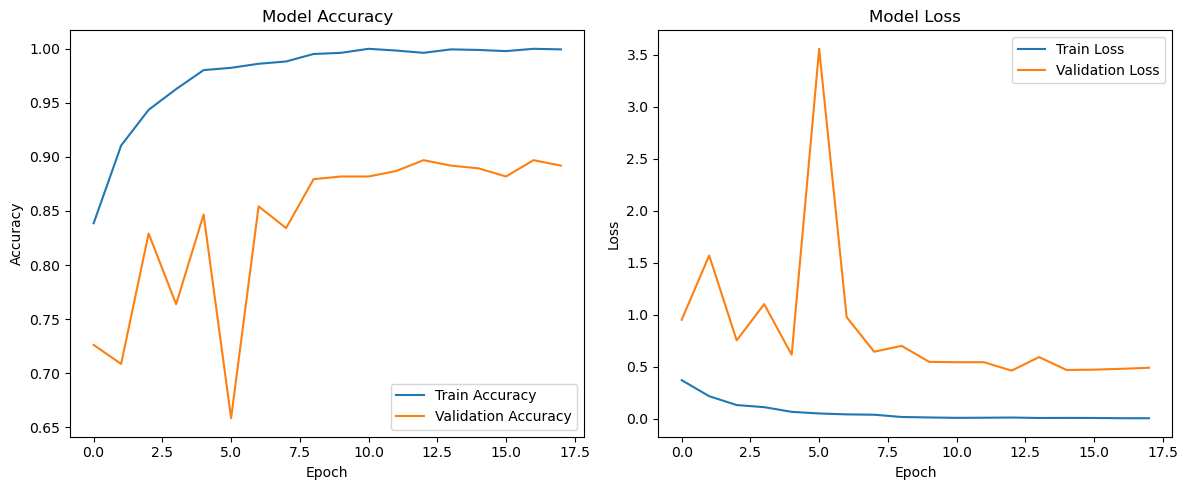

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step


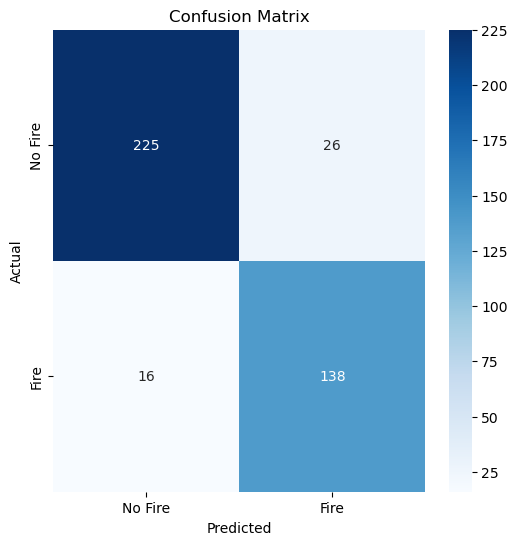


Classification Report:
              precision    recall  f1-score   support

     No Fire       0.93      0.90      0.91       251
        Fire       0.84      0.90      0.87       154

    accuracy                           0.90       405
   macro avg       0.89      0.90      0.89       405
weighted avg       0.90      0.90      0.90       405

INFO:tensorflow:Assets written to: C:\Users\victory\AppData\Local\Temp\tmpf1kllmaw\assets


INFO:tensorflow:Assets written to: C:\Users\victory\AppData\Local\Temp\tmpf1kllmaw\assets


Saved artifact at 'C:\Users\victory\AppData\Local\Temp\tmpf1kllmaw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1968281446800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1968281448144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1968281437584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1968281448528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1968281447760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1968281448720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1968281449296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1968281448912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1968281448336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1968281447568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  196

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ======================================
# 1. GPU Setup and Path Configuration
# ======================================
# Enable GPU acceleration
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

# Define base path (MODIFY THIS TO YOUR ACTUAL PATH)
dataset_base = "C:/Users/victory/anaconda3/envs/drone_env/Fire-Detection-Image-Processing/Image_Dataset"

# ======================================
# 2. Robust Data Pipeline
# ======================================
def validate_and_build_dataset(data_dir, batch_size=32, augment=False, target_size=(160, 160)):
    """Builds a validated tf.data pipeline with error checking"""
    # Convert to cross-platform path
    data_dir = os.path.normpath(data_dir)
    
    # Verify directory exists
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"Directory not found: {data_dir}")
    
    # Verify class subdirectories
    class_names = ['fire', 'nofire']
    for class_name in class_names:
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            raise ValueError(f"Missing required subdirectory: {class_dir}")
        
        num_images = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"Found {num_images} images in {class_dir}")

    # Build dataset with proper path handling
    list_ds = tf.data.Dataset.list_files(
        os.path.join(data_dir, '*', '*.jpg').replace("\\", "/"),
        shuffle=augment
    )
    
    def process_path(file_path):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, target_size)
        img = img / 255.0  # Normalization
        
        # Get label from parent folder
        label = tf.strings.split(file_path, os.sep)[-2]
        label = tf.where(label == 'fire', 1, 0)
        return img, label
    
    # Apply augmentation if needed
    def augment_img(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)
        return img, label
    
    ds = list_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_img, num_parallel_calls=tf.data.AUTOTUNE)
    
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# ======================================
# 3. Dataset Loading with Validation
# ======================================
try:
    print("\nLoading training data...")
    train_ds = validate_and_build_dataset(
        os.path.join(dataset_base, "train"),
        augment=True,
        target_size=(160, 160)
    )
    
    print("\nLoading validation data...")
    val_ds = validate_and_build_dataset(
        os.path.join(dataset_base, "val"),
        target_size=(160, 160)
    )
    
    print("\nLoading test data...")
    test_ds = validate_and_build_dataset(
        os.path.join(dataset_base, "test"),
        target_size=(160, 160)
    )
    
except Exception as e:
    print(f"\nERROR: {str(e)}")
    print("Please verify:")
    print(f"1. The base path exists: {dataset_base}")
    print("2. Subdirectories 'train', 'validation', 'test' exist")
    print("3. Each has 'fire' and 'no_fire' subfolders with images")
    exit()

# ======================================
# 4. Model Definition
# ======================================
base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(160, 160, 3),
    alpha=0.5  # Smaller model
)

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# ======================================
# 5. Training with Visualization
# ======================================
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.1, patience=3)
]

print("\nStarting training...")
history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

# ======================================
# 6. Evaluation and Visualization
# ======================================
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

def evaluate_model(model, test_ds):
    # Get all predictions and labels
    y_true = []
    y_pred = []
    
    for images, labels in test_ds:
        y_true.extend(labels.numpy())
        y_pred.extend((model.predict(images) > 0.5).astype(int).flatten())
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Fire', 'Fire'],
                yticklabels=['No Fire', 'Fire'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Fire', 'Fire']))

# Generate plots
plot_training_history(history)
evaluate_model(model, test_ds)

# ======================================
# 7. Model Export
# ======================================
model.save('fire_detection_model.h5')

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('fire_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("\nTraining complete! Saved:")
print("- fire_detection_model.h5 (Keras model)")
print("- fire_model.tflite (Optimized for deployment)")
print("- training_history.png (Training curves)")
print("- confusion_matrix.png (Performance visualization)")

In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ======================================
# 1. Configuration
# ======================================
# Set your dataset path (MODIFY THIS)
DATASET_BASE = "C:/Users/victory/anaconda3/envs/drone_env/Fire-Detection-Image-Processing/Image_Dataset"
OUTPUT_DIR = "Output_Dataset"
TARGET_SIZE = (160, 160)
BATCH_SIZE = 32

# ======================================
# 2. Data Pipeline
# ======================================
def build_dataset(data_dir, augment=False):
    """Build optimized tf.data pipeline"""
    data_dir = os.path.normpath(data_dir)
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"Directory not found: {data_dir}")

    # Count images for verification
    for class_name in ['fire', 'nofire']:
        class_dir = os.path.join(data_dir, class_name)
        num_images = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"Found {num_images} images in {class_dir}")

    # Build dataset
    list_ds = tf.data.Dataset.list_files(os.path.join(data_dir, '*', '*.jpg').replace("\\", "/"), shuffle=augment)
    
    def process_path(file_path):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, TARGET_SIZE)
        img = img / 255.0
        
        label = tf.strings.split(file_path, os.sep)[-2]
        label = tf.where(label == 'fire', 1, 0)
        return img, label
    
    def augment_img(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
        return img, label
    
    ds = list_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_img, num_parallel_calls=tf.data.AUTOTUNE)
    
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ======================================
# 3. Model Training
# ======================================
def train_model():
    # Load datasets
    train_ds = build_dataset(os.path.join(DATASET_BASE, "train"), augment=True)
    val_ds = build_dataset(os.path.join(DATASET_BASE, "val"))
    test_ds = build_dataset(os.path.join(DATASET_BASE, "test"))

    # Model architecture
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(*TARGET_SIZE, 3), alpha=0.5)
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu')(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=predictions)

    # Freeze base layers
    for layer in base_model.layers[:-4]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    # Train with callbacks
    callbacks = [
        EarlyStopping(patience=5, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.1, patience=3)
    ]

    history = model.fit(
        train_ds,
        epochs=30,
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate
    test_results = model.evaluate(test_ds)
    print(f"\nTest Accuracy: {test_results[1]*100:.2f}%")
    print(f"Test Precision: {test_results[2]*100:.2f}%")
    print(f"Test Recall: {test_results[3]*100:.2f}%")

    # Save model
    model.save('fire_detection_model.h5')
    print("\nModel saved as fire_detection_model.h5")
    
    return model

# ======================================
# 4. Visualization & Detection
# ======================================
def visualize_results(model, test_dir):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # Process all test images
    test_images = []
    for root, _, files in os.walk(test_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                test_images.append(os.path.join(root, file))
    
    for img_path in test_images:
        try:
            # Read and preprocess
            img = cv2.imread(img_path)
            rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            resized = cv2.resize(rgb_img, TARGET_SIZE)
            normalized = resized / 255.0
            input_arr = np.expand_dims(normalized, axis=0)
            
            # Predict
            pred = model.predict(input_arr)[0][0]
            
            if pred > 0.7:  # Confidence threshold
                # Find fire region using brightness
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
                contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
                
                if contours:
                    largest_contour = max(contours, key=cv2.contourArea)
                    (x, y), radius = cv2.minEnclosingCircle(largest_contour)
                    
                    # Draw markings
                    cv2.circle(img, (int(x), int(y)), int(radius), (0, 0, 255), 2)
                    cv2.putText(img, f"Fire ({pred:.2f})", (int(x), int(y)-10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2)
            
            # Save result
            output_path = os.path.join(OUTPUT_DIR, os.path.basename(img_path))
            cv2.imwrite(output_path, img)
            print(f"Processed: {os.path.basename(img_path)} -> {output_path}")
            
        except Exception as e:
            print(f"Error processing {img_path}: {str(e)}")

# ======================================
# 5. Main Execution
# ======================================
if __name__ == "__main__":
    # Train or load model
    if os.path.exists('fire_detection_model.h5'):
        model = load_model('fire_detection_model.h5')
        print("Loaded pre-trained model")
    else:
        print("Training new model...")
        model = train_model()
    
    # Visualize detections
    test_dir = os.path.join(DATASET_BASE, "test")
    visualize_results(model, test_dir)
    
    print("\nProcess completed! Check the Output_Dataset folder for results.")

Loaded pre-trained model
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
Processed: 19196558588_267f24b847_o.jpg -> Output_Dataset\19196558588_267f24b847_o.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Processed: 20960888741_8c4be2c1df_o.jpg -> Output_Dataset\20960888741_8c4be2c1df_o.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Processed: 26131736898_9e6a8cd68f_o.jpg -> Output_Dataset\26131736898_9e6a8cd68f_o.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Processed: 26549039025_b4cce14ec7_o.jpg -> Output_Dataset\26549039025_b4cce14ec7_o.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Processed: 27002088114_aa5cc7f353_o.jpg -> Output_Dataset\27002088114_aa5cc7f353_o.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Processed: 27335331950_39b376eddd_o.jpg -> Output_Dataset\27335331950_39b376eddd_o.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Processed: 27389369514_cd30397ac2_o.jpg -> Output_Dataset\27389369514_cd30397ac2_o.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Processed: 27951228213_2dd961ac1f_o.jpg -> Output_Dataset\279

KeyboardInterrupt: 